## SQL 數據萃取與加工
```sql
SELECT 
    Favorite_Genre,
    Subscription_Type,
    ROUND(AVG(Watch_Time), 1) AS 平均觀看小時
FROM 
    netflix_users
GROUP BY 
    Favorite_Genre, 
    Subscription_Type
ORDER BY 
    Favorite_Genre, 
    平均觀看小時 DESC;

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [57]:
netflix_summary = pd.read_csv("NetFlix_summary.csv")

In [58]:
print(netflix_summary)

   Favorite_Genre Subscription_Type  平均觀看小時
0           Drama             Basic  545.41
1         Romance             Basic  539.17
2          Action           Premium  538.69
3          Sci-Fi             Basic  532.62
4           Drama           Premium  519.10
5          Comedy           Premium  514.08
6          Comedy          Standard  511.46
7     Documentary           Premium  505.99
8          Action             Basic  501.83
9          Comedy             Basic  499.58
10        Romance           Premium  499.32
11        Romance          Standard  497.44
12    Documentary             Basic  494.34
13         Horror           Premium  494.26
14    Documentary          Standard  487.35
15         Horror             Basic  483.53
16          Drama          Standard  478.38
17         Horror          Standard  450.53
18         Action          Standard  436.31
19         Sci-Fi           Premium  434.74
20         Sci-Fi          Standard  398.27


In [62]:
print(netflix_summary.isnull().sum())

Favorite_Genre       0
Subscription_Type    0
平均觀看小時               0
dtype: int64


In [59]:
plt.rcParams['font.family'] = ['Microsoft JhengHei']

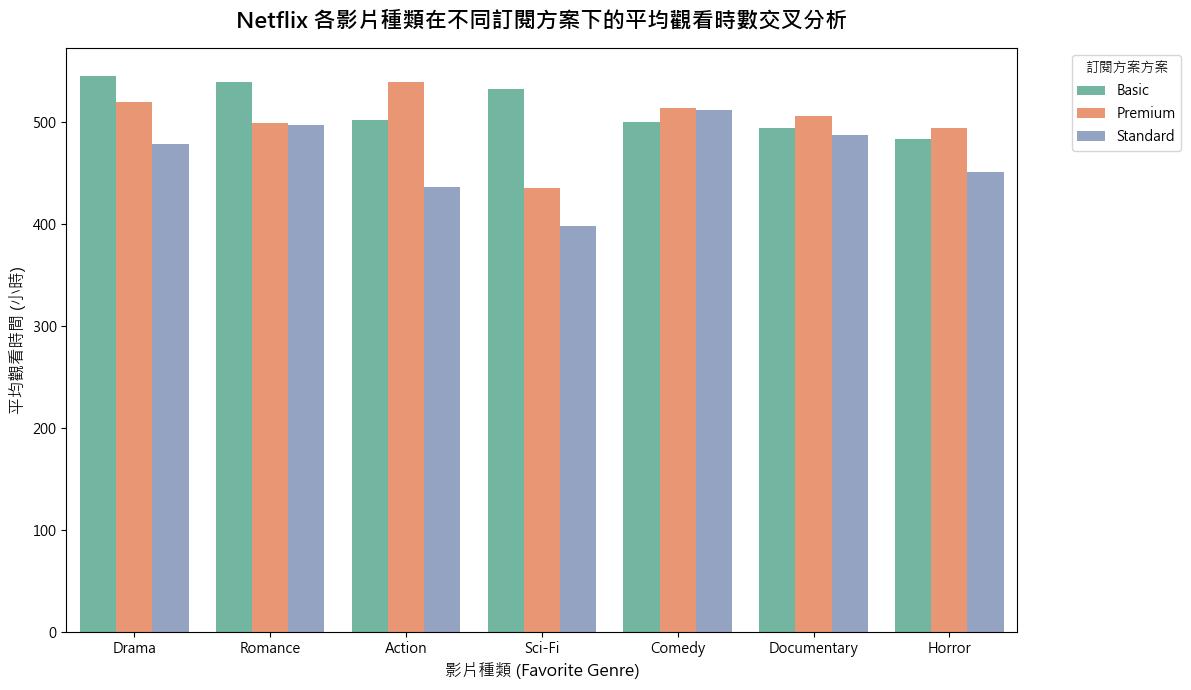

In [60]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Favorite_Genre', y='平均觀看小時', hue='Subscription_Type', data=netflix_summary, palette='Set2')
plt.title('Netflix 各影片種類在不同訂閱方案下的平均觀看時數交叉分析', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('影片種類 (Favorite Genre)', fontsize=12)
plt.ylabel('平均觀看時間 (小時)', fontsize=12)

# 5. 調整圖例（Legend）的位置，讓它不要擋到圖表
plt.legend(title='訂閱方案方案', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. 自動排版並顯示
plt.tight_layout()
plt.show()

### 專案核心洞察:
* **Basic**--多數用戶選擇Basic方案各影片種類觀看時數、類型較為平均
* **Permium**--Premium方案類型也相對平均但科幻片有明顯差異，與其他Permium影片類型觀看時數將近快差了一百個小時
* **Standard**--Standard方案與其他方案有最為顯著的差異，尤其以非科幻片/動作片差異最大，說明標準方案會員的偏好較為極端

### 行動建議:
鎖定Basic客戶，未來在推廣方案時，祭出專屬的升級誘因（例如:升級Permium或Standard方案，與家人共享高清雙螢幕追劇) 作為推廣